# Kolmogorov-Arnold Network (KAN)
### A Rede Neural que está enterrando as MLPs?!?!

---

## 1. Abertura

As MLPs sustentam praticamente todas as teorias e técnicas de Deep Learning desde os 80:

- Paper do MIT chamado *'KAN: Kolmogorov-Arnold Networks'* (Abril de 2024)
- Promessa de redes menores, mais precisas e **interpretáveis**.

## 2. O Teorema de Kolmogorov-Arnold (1957)

**Qualquer** função contínua multivariada pode ser escrita como uma soma finita de composições de funções contínuas de **uma variável**:
$f(x_1, \dots, x_n) = \sum_{q=1}^{2n+1} \Phi_q\left( \sum_{p=1}^{n} \phi_{q,p}(x_p) \right)$


O paper **parametriza essas funções φ como redes neurais**, generalizando a fórmula pra múltiplas camadas.

### A inversão estrutural: onde mora o aprendizado

| | **MLP** | **KAN** |
|---|---|---|
| Nas **arestas** | peso escalar $w$ (fixo, linear) | função **$\phi(x)$** aprendida (spline) |
| Nos **nós** | soma + ativação **fixa** (ReLU, GELU...) | soma **pura** |
| O que a rede aprende | valores dos pesos $w$ e vieses $b$ | a **forma** de cada função $\phi$ (pontos de controle da spline) |
| Onde vive a não-linearidade | nos nós, é a mesma em todo lugar | nas arestas, é diferente em cada uma |

Na MLP, a rede escolhe **quanto** usar de uma ativação fixa. Na KAN, a rede escolhe **qual** função usar em cada conexão.

### Por que isso importa na prática

- Cada função $\phi(x)$ pode ser **plotada** → você vê o que a rede aprendeu → **interpretabilidade**.
- Em funções composicionais poucas splines bem colocadas podem substituir muitos neurônios de MLP.
- O preço: calcular splines é muito mais caro que multiplicar matrizes (GPU adora `matmul`, não adora spline).

## 3. Setup do Experimento

Vamos aproximar aproximar uma função de duas variáveis que mistura seno e polinômioa. Função complexa. $f(x, y) = e^{\sin(\pi x) + y^2}$

Vamos treinar **uma MLP** e **uma KAN** no mesmo dataset, com orçamento de parâmetros parecido, e comparar:
1. Erro final (MSE)
2. Tempo de treino
3. Número de parâmetros
4. Interpretabilidade (dá pra "ler" a função aprendida?)

In [1]:
import torch, math, time

from matplotlib import pyplot

torch.manual_seed(42)
device = 'cpu'

def target_fn(x, y):
    return torch.exp(torch.sin(math.pi * x) + y ** 2)

# dataset: pontos aleatorios em [-1, 1] x [-1, 1]
N_TRAIN, N_TEST = 1000, 200
X_train = torch.rand(N_TRAIN, 2) * 2 - 1
y_train = target_fn(X_train[:, 0], X_train[:, 1]).unsqueeze(1)

X_test = torch.rand(N_TEST, 2) * 2 - 1
y_test = target_fn(X_test[:, 0], X_test[:, 1]).unsqueeze(1)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
print(f'f(x,y) varia de {y_train.min():.3f} a {y_train.max():.3f}')

Treino: torch.Size([1000, 2]) | Teste: torch.Size([200, 2])
f(x,y) varia de 0.369 a 7.268


## 4. Construindo a MLP (baseline)

Nada de especial aqui: `Linear → ativação → Linear`.

In [2]:
class MLP(torch.nn.Module):
    
    def __init__(self, layers_hidden, activation=torch.nn.SiLU):
        super().__init__()
        
        mods = []
        for i in range(len(layers_hidden) - 1):
            mods.append(torch.nn.Linear(layers_hidden[i], layers_hidden[i + 1]))
            if i < len(layers_hidden) - 2:
                mods.append(activation())
        
        self.net = torch.nn.Sequential(*mods)

    def forward(self, x):
        return self.net(x)

Funções comuns.

In [3]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

def train_model(model, X, y, steps=500, lr=0.01, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    t0 = time.time()
    for step in range(steps):
        opt.zero_grad()
        pred = model(X)
        loss = torch.nn.functional.mse_loss(pred, y)
        loss.backward()
        opt.step()
        if step % log_every == 0 or step == steps - 1:
            history.append((step, loss.item()))
    
    elapsed = time.time() - t0
    return {'model': model, 'history': history, 'final_loss': loss.item(), 'time': elapsed} # type: ignore

# arquitetura: 2 entradas -> 8 neuronios ocultos -> 1 saída
mlp = MLP([2, 8, 1])
print(f'MLP tem {count_params(mlp)} parâmetros')

MLP tem 33 parâmetros


In [4]:
mlp_result = train_model(mlp, X_train, y_train, steps=500, lr=0.01)
print(f'[MLP] loss final de treino: {mlp_result["final_loss"]:.5f}')
print(f'[MLP] tempo de treino: {mlp_result["time"]:.3f}s')

with torch.no_grad():
    mlp_test_loss = torch.nn.functional.mse_loss(mlp(X_test), y_test).item()
print(f'[MLP] loss no teste: {mlp_test_loss:.5f}')

[MLP] loss final de treino: 0.71197
[MLP] tempo de treino: 0.086s
[MLP] loss no teste: 0.68238


## 5 Construindo a KAN

Cada `KANLinear` guarda, para cada par (entrada x saída), uma **B-spline** learnable.

> Não tem `nn.ReLU()` em lugar nenhum aqui. A não-linearidade inteira mora dentro de `b_splines`.

**Um conceito fundamental muda**:

Deixa de ser $y = \sigma(w \cdot x + b)$ e passa a ser $y = \sum_i \phi_i(x_i)$. Ou seja: em vez de aprender um **número** por aresta, a rede aprende uma **curva**. Para isso, entra em campo a B-Spline:

B-Spline = uma curva montada somando "montinhos" com alturas aprendidas: $\phi(x) = \sum_{i} c_i \cdot B_i(x)$

- **Grid (nós):** marcações fixas no eixo x que dividem o domínio em trechos. `grid_size=5` → 5 trechos entre -1 e 1. **Não é treinado.**
- **Bases $B_i(x)$:** os "montinhos". Cada um cobre só alguns trechos do grid e vale zero fora deles. Para um dado x, só `spline_order + 1` = 4 montinhos estão ativos. Por aresta são `grid_size + spline_order` = **8 bases**.
- **Coeficientes $c_i$ (`spline_weight`):** a altura de cada montinho. **É isso que a rede aprende.**
- **Efeito local:** mexer em um $c_i$ deforma a curva só naquela região, sem estragar o resto.
- **`left` e `right`:** é como cada montinho é construído. Começa como um degrau ("x está neste trecho?") e cada rodada suaviza: `left` é a rampa de **subida**, `right` é a rampa de **descida**.

> **MLP** aprende o valor de $w$. **KAN** aprende os valores de $c_i$, que definem a forma de $\phi$.

In [5]:
class KANLinear(torch.nn.Module):
    
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3, grid_range=(-1, 1)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        # grade de nos da spline (estendida nas bordas por causa da ordem do polinomio)
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0])
        grid = grid.expand(in_features, -1).contiguous()
        self.register_buffer("grid", grid)

        # "peso base" (funciona como um residuo tipo skip-connection) + coeficientes da spline
        self.base_weight = torch.nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.empty(out_features, in_features, grid_size + spline_order)
        )
        
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
        torch.nn.init.normal_(self.spline_weight, mean=0.0, std=0.1)
        self.base_act = torch.nn.ReLU()

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)                # type: ignore
        for k in range(1, self.spline_order + 1):
            left = (x - grid[:, : -(k + 1)]) / (grid[:, k:-1] - grid[:, : -(k + 1)]) # type: ignore
            right = (grid[:, k + 1 :] - x) / (grid[:, k + 1 :] - grid[:, 1:-k])      # type: ignore
            bases = left * bases[:, :, :-1] + right * bases[:, :, 1:]
        
        return bases  # [batch, in_features, grid_size + spline_order]

    def forward(self, x):
        base_output = torch.nn.functional.linear(self.base_act(x), self.base_weight)
        spline_basis = self.b_splines(x).view(x.size(0), -1)
        spline_output = torch.nn.functional.linear(spline_basis, self.spline_weight.view(self.out_features, -1))
        return base_output + spline_output

class KAN(torch.nn.Module):
    def __init__(self, layers_hidden, grid_size=5, spline_order=3):
        super().__init__()
        self.layers = torch.nn.ModuleList([
            KANLinear(in_f, out_f, grid_size=grid_size, spline_order=spline_order) for in_f, out_f in zip(layers_hidden, layers_hidden[1:])
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        
        return x

# mesmo "shape" externo da MLP: 2 -> 8 -> 1
kan = KAN([2, 8, 1])
print(f'KAN tem {count_params(kan)} parâmetros (MLP tinha {count_params(mlp)})')
print('Mesmo shape externo, muito mais parâmetros. Cada aresta carrega uma spline')

KAN tem 216 parâmetros (MLP tinha 33)
Mesmo shape externo, muito mais parâmetros. Cada aresta carrega uma spline


**Exemplo gráfico**

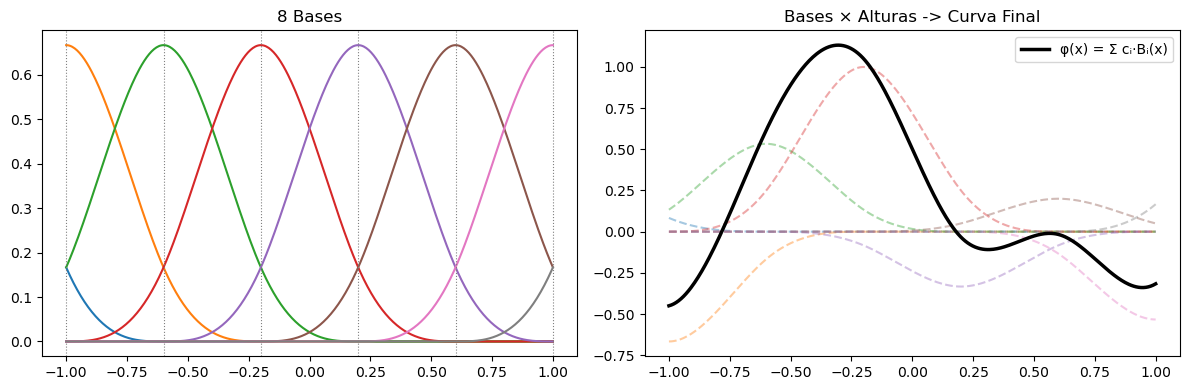

In [6]:
layer = KANLinear(1, 1, grid_size=5, spline_order=3)
x = torch.linspace(-1, 1, 400).unsqueeze(1)

with torch.no_grad():
    B = layer.b_splines(x)[:, 0, :]                            # [400, 8]: os 8 "montinhos"

c = torch.tensor([0.5, -1.0, 0.8, 1.5, -0.5, 0.3, -0.8, 1.0])  # alturas (o que a rede aprenderia)
phi = B @ c                                                    # φ(x) = Σ cᵢ·Bᵢ(x)

fig, ax = pyplot.subplots(1, 2, figsize=(12, 4))

for i in range(B.shape[1]):
    ax[0].plot(x, B[:, i])
    ax[1].plot(x, c[i] * B[:, i], ls='--', alpha=0.4)
for g in layer.grid[0, 3:-3]: # type: ignore
    ax[0].axvline(g, color='gray', ls=':', lw=0.8)

ax[1].plot(x, phi, color='black', lw=2.5, label='φ(x) = Σ cᵢ·Bᵢ(x)')
ax[0].set_title('8 Bases')
ax[1].set_title('Bases × Alturas -> Curva Final')
ax[1].legend()
pyplot.tight_layout(); pyplot.show()

**Treinando KAN**

In [7]:
kan_result = train_model(kan, X_train, y_train, steps=500, lr=0.01)
print(f'[KAN] loss final de treino: {kan_result["final_loss"]:.5f}')
print(f'[KAN] tempo de treino: {kan_result["time"]:.3f}s')

with torch.no_grad():
    kan_test_loss = torch.nn.functional.mse_loss(kan(X_test), y_test).item()

print(f'[KAN] loss no teste: {kan_test_loss:.5f}')

[KAN] loss final de treino: 0.00044
[KAN] tempo de treino: 0.918s
[KAN] loss no teste: 0.00050


## 6. Confronto

In [8]:
print(f"{'':15s}{'MLP':>15s}{'KAN':>15s}")
print(f"{'Parâmetros':15s}{count_params(mlp):>15d}{count_params(kan):>15d}")
print(f"{'Loss treino':15s}{mlp_result['final_loss']:>15.5f}{kan_result['final_loss']:>15.5f}")
print(f"{'Loss teste':15s}{mlp_test_loss:>15.5f}{kan_test_loss:>15.5f}")
print(f"{'Tempo (s)':15s}{mlp_result['time']:>15.3f}{kan_result['time']:>15.3f}")
print(f"{'ms / parâmetro':15s}{1000*mlp_result['time']/count_params(mlp):>15.4f}{1000*kan_result['time']/count_params(kan):>15.4f}")

                           MLP            KAN
Parâmetros                  33            216
Loss treino            0.71197        0.00044
Loss teste             0.68238        0.00050
Tempo (s)                0.086          0.918
ms / parâmetro          2.6191         4.2521


A KAN erra menos, mas treina mais devagar. Isso **não é bug de implementação, é estrutural**! `Alguma objeção`?

In [9]:
# nro de parametros de referencia (KAN)
target_params = count_params(kan)

def mlp_params_for_hidden(h):
    return (2 * h + h) + (h * 1 + 1)

# busca simples pelo hidden size mais proximo do orcamento da KAN
best_h = min(range(4, 200), key=lambda h: abs(mlp_params_for_hidden(h) - target_params))
print(f'KAN tem {target_params} parâmetros -> MLP com hidden={best_h} tem {mlp_params_for_hidden(best_h)} parâmetros')

mlp_fair = MLP([2, best_h, 1])
mlp_fair_result = train_model(mlp_fair, X_train, y_train, steps=500, lr=0.01)

with torch.no_grad():
    mlp_fair_test_loss = torch.nn.functional.mse_loss(mlp_fair(X_test), y_test).item()

print(f"{'':22s}{'MLP (mesmo orçamento)':>22s}{'KAN':>15s}")
print(f"{'Parâmetros':22s}{count_params(mlp_fair):>22d}{count_params(kan):>15d}")
print(f"{'Loss teste':22s}{mlp_fair_test_loss:>22.5f}{kan_test_loss:>15.5f}")
print(f"{'Tempo (s)':22s}{mlp_fair_result['time']:>22.3f}{kan_result['time']:>15.3f}")

KAN tem 216 parâmetros -> MLP com hidden=54 tem 217 parâmetros
                       MLP (mesmo orçamento)            KAN
Parâmetros                               217            216
Loss teste                           0.04524        0.00050
Tempo (s)                              0.146          0.918


Com orçamento de parâmetros igual, a MLP melhora. A KAN continua `vencendo em erro` e `perdendo em velocidade`.

### Curvas de Treino

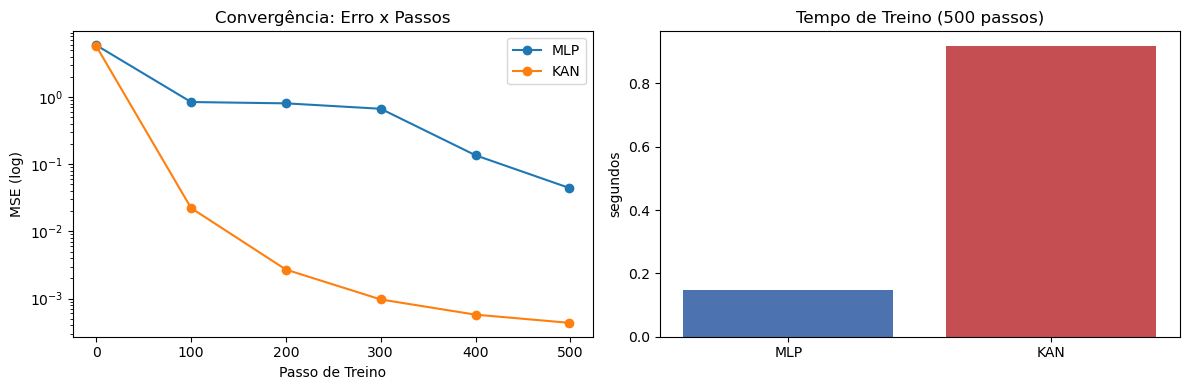

In [10]:
fig, ax = pyplot.subplots(1, 2, figsize=(12, 4))

steps_mlp, losses_mlp = zip(*mlp_fair_result['history'])
steps_kan, losses_kan = zip(*kan_result['history'])

ax[0].plot(steps_mlp, losses_mlp, label='MLP', marker='o')
ax[0].plot(steps_kan, losses_kan, label='KAN', marker='o')
ax[0].set_yscale('log')
ax[0].set_xlabel('Passo de Treino')
ax[0].set_ylabel('MSE (log)')
ax[0].set_title('Convergência: Erro x Passos')
ax[0].legend()

ax[1].bar(['MLP', 'KAN'], [mlp_fair_result['time'], kan_result['time']], color=['#4C72B0', '#C44E52'])
ax[1].set_ylabel('segundos')
ax[1].set_title('Tempo de Treino (500 passos)')

pyplot.tight_layout()
pyplot.show()

### Interpretabilidade

Função univariada aprendida em cada aresta da primeira camada da KAN. É possível comparar com os "ingredientes" reais da função-alvo ($\sin(\pi x)$ e $y^2$).

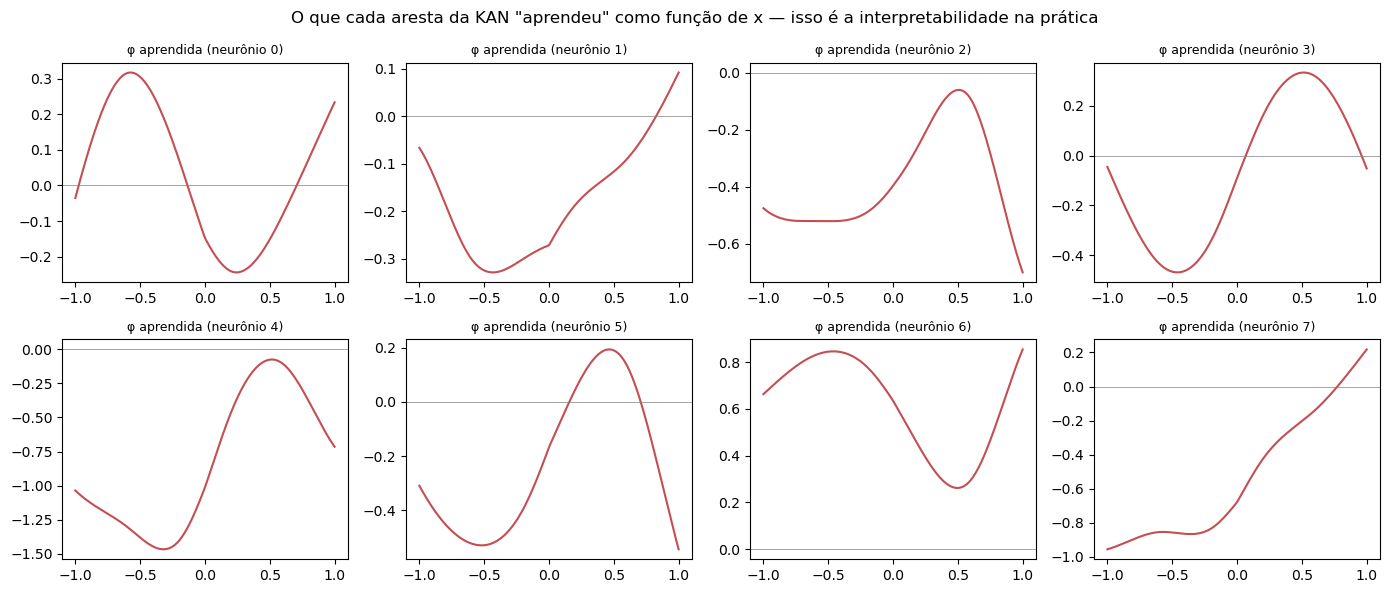

Compare essas formas com sin(πx): é isso que a plateia deve tentar reconhecer visualmente.


In [ ]:
layer0 = kan.layers[0]  # primeira camada: 2 entradas -> 8 "neuronios" ocultos

x_plot = torch.linspace(-1, 1, 200)

fig, axes = pyplot.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

with torch.no_grad():
    for neuron in range(8):
        ax = axes[neuron]
        # funcao aprendida olhando so pra entrada x0, mantendo x1 fixo em 0
        inp = torch.zeros(200, 2)
        inp[:, 0] = x_plot
        base = layer0.base_act(inp) @ layer0.base_weight.T                              # type: ignore
        spline_basis = layer0.b_splines(inp).reshape(200, -1)                           # type: ignore
        spline = spline_basis @ layer0.spline_weight.reshape(layer0.out_features, -1).T # type: ignore
        phi = (base + spline)[:, neuron]

        ax.plot(x_plot, phi.numpy(), color='#C44E52')
        ax.set_title(f'φ aprendida (neurônio {neuron})', fontsize=9)
        ax.axhline(0, color="gray", lw=0.5)

pyplot.suptitle('Aprendizado de cada aresta como função de X')
pyplot.tight_layout()
pyplot.show()

print('Compare essas formas com sin(πx): é isso que a plateia deve tentar reconhecer visualmente.')

## 7. Vantagens e Desvantagens

### ✅ Vantagens da KAN

- **Interpretabilidade real**: dá pra plotar e ler cada φ(x), extrair fórmulas simbólicas.
- **Eficiência paramétrica em funções suaves e de baixa dimensão**: menos erro com arquitetura de mesmo "formato".
- Ótima para **regressão simbólica** e recuperação das funções de regimento.

### ❌ Desvantagens da KAN

- **Treino mais lento**: várias vezes mais lento que a MLP equivalente.
- **Escala mal em alta dimensão**:cada aresta carrega uma spline inteira, não um escalar.
- **Sensível a hiperparâmetros** de grid/ordem da spline.
- **Ecossistema imaturo**: pouco otimizado para GPU, pouco testado em produção.

### 🎯 Quando usar

| Cenário                                                                   | Use                                                  |
|---------------------------------------------------------------------------|------------------------------------------------------|
| Visão computacional, NLP, tabular, produção com restrição de tempo/custo  | **MLP**                                              |
| Regressão simbólica, poucas variáveis, precisa explicar o modelo          | **KAN**                                              |
| Não sabe / caso genérico                                                  | **MLP** primeiro — é o baseline mais rápido e maduro |

## 8. Conclusão Honesta

**Fala sugerida:**

A KAN não está 'enterrando' as MLPs, ela abre uma frente nova:

- Entrega interpretabilidade (ótima para problemas científicos)
- Custo alto em velocidade e maturidade
- Para o que enfrentamos em produção, MLP (Deep Learning tradicional) continua sendo escolho certa

> Vale manter na caixa de ferramentas.